In [ ]:
# Simple Linear Regression SLR
# Supervised Learning Algorithm
# Used to predict continous numeric value
# but based on only one independent variable
# Area	Bedrooms	Bathrooms	Material	Locality  - features, independent
# HousePrice - Target , dependent
# SLR -> which predict output based on only one variable

# Steps for implementing ML Workflow:
# Collect data
# Preprocess data - cleaning, transformation
# Split the data - Divide data into - two sets - training set, testing set
#                - machine learns using training set - 80% of data
#                - test machine using testing set - 20% of data
# Train the model
# Evaluate model - metrics available - r2_score, mean squared error, accuracy score
#                - performs well on metrics then we will predict
#                - model does not perform well, reject the model
# Predictions are done

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load dataset
df = pd.read_csv("house.csv")
df.head()

,Area,Bedrooms,Bathrooms,Material,Locality,Price
0,1790,2,2,Concrete,Riverside,114300
1,2030,4,2,Concrete,Riverside,114200
2,1740,3,2,Concrete,Riverside,114800
3,1980,3,2,Concrete,Riverside,94700
4,2130,3,3,Concrete,Riverside,119800


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       128 non-null    int64 
 1   Bedrooms   128 non-null    int64 
 2   Bathrooms  128 non-null    int64 
 3   Material   128 non-null    object
 4   Locality   128 non-null    object
 5   Price      128 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 6.1+ KB


In [7]:
# Select feature and target variable from the dataset
# implementing simple linear regression - take only one feature
# Feature - 'Area' as single feature
# features - X
# target - y

X = df[['Area']]   # [[]] -> ML algos take features as 2 dimensional, target as 1D
y = df['Price']

In [11]:
# Split into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
                      # 20% goes to testing set, 20% of 128
                      # random_state - used for reproducability, same split will be done

# 128 rows - 80 - 20 ratio

In [13]:
# Train the model

# initiate the algorithm
model = LinearRegression()
# Fit the training set - model will learn patterns from the training dataset
model.fit(X_train, y_train)
# -> fit the best possible regression line using the training data

# copy_x -> copied the training data
# tol -> tolerance , stopping criteria 
# n_jobs -> How many CPU cores are used
# m ccan be negative also

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


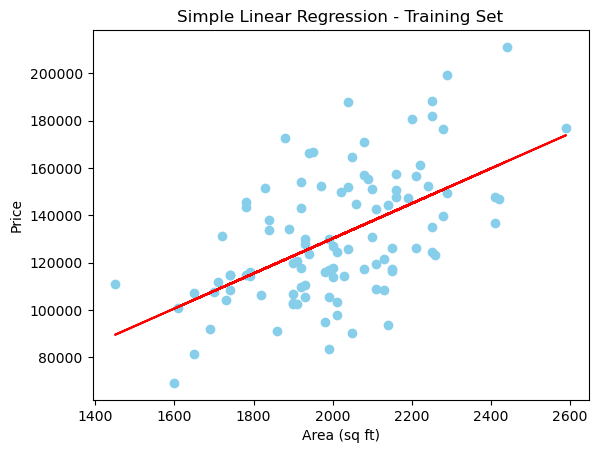

In [15]:
# Visualize the regression line

plt.scatter(X_train, y_train, color='skyblue', label='Training Data')
plt.plot(X_train, model.predict(X_train), color='red', label='Regression Line')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.title('Simple Linear Regression - Training Set')
plt.show()
    
# y = mx+c

In [17]:
# y_train -> given to the model

# X_test, y_test -> testing set -> not given to model
# for every X_test value - we will ask model to predict y_test_pred value
# actual y_test we have 
# comparison b/w y_test and y_test_pred
# evaluate the model - metrics - r2score, mean squared error

y_test_pred = model.predict(X_test)
print(y_test, y_test_pred)

55     125700
40     106600
19     167200
31     112300
98     145500
56     140900
69     165600
104     82300
81     184300
26     137000
94     160600
27      99300
64     130300
4      119800
96     133300
113    115700
36     117500
80     143400
125    113500
84      90500
18     111400
10     132500
118    150200
11     123000
105    146900
45     103200
Name: Price, dtype: int64 [109451.07078841  97605.44963186 124258.0972341  124998.44855638
 134623.01574608 144247.58293577 136103.71839065 123517.74591181
 140545.82632435 130180.90781237 141286.17764664 107970.36814384
 119815.98930039 139805.47500207 162756.36599289 130180.90781237
 121296.69194496 144247.58293577 135363.36706836  94644.04434272
 107970.36814384 132401.96177922 126479.15120095 120556.34062267
 169419.52789345 116114.23268897]


In [21]:
# Evaluate the model based on predictions
# mean squared error :
# y_test and y_test_pred -> (error)^2 -> average of it
# RMSE : sqrt of MSE, Root  
import numpy as np
print("Testing Data : RMSE", np.sqrt(mean_squared_error(y_test, y_test_pred)))
# RMSE indicating how far predicted values are from actual values
# ideally it should low -> predictions are good

Testing Data : RMSE 20390.33694280305


In [25]:
# R2 score 
# another metric 
print("Testing Data : r2_score", r2_score(y_test, y_test_pred))
# R2 score tells how well your regression model fits the data
# measure of goodness of fit
# R2 = 1 -> Perfect fit - predictions match actual values
# R2 = 0 -> model preditcs as same as mean, not better than  mean
# R2 < 0 -> model performs worse , reject the model
# ideally it should be more near to 1

Testing Data : r2_score 0.2945934454247471
